# Problem 1

In [1]:
import numpy as np
import numpy.linalg as lin
import matplotlib.pyplot as plt

In [2]:
def QR_decompose(A):
    # Function for QR decomposition using Gram-Schmidt process
    # A: input, a real square matrix

    n, m = np.shape(A)
    # A = Q@R
    A = A.astype(float) # turn int -> float
    Q = np.zeros_like(A) # orthogonal matrix
    R = np.zeros_like(A) # upper-triangular matrix

    for i in range(n):
        a_i = np.copy(A[:, i])
        u = np.copy(a_i)

        for j in range(i):
            q_j = np.copy(Q[:, j])
            u -= q_j*(q_j@a_i)
            R[j, i] = q_j@a_i

        Q[:, i] = u/lin.norm(u)
        R[i, i] = lin.norm(u)

    return Q, R


A = np.array([[1, 4, 8, 4],
              [4, 2, 3, 7],
              [8, 3, 6, 9],
              [4, 7, 9, 2]])

q, r = QR_decompose(A)
print(q@r)

[[1. 4. 8. 4.]
 [4. 2. 3. 7.]
 [8. 3. 6. 9.]
 [4. 7. 9. 2.]]


In [3]:
def QR_algorithm(A, c=1E-6):
    # Solving eigenvalue problem using QR decomposition
    # A: input, a real square matrix
    # c: stop condition

    A_k = np.copy(A).astype(float)
    mask = ~np.eye(np.shape(A)[0], dtype=bool) # for checking non-diagonal elements
    
    V = np.eye(np.shape(A)[0], dtype=float) # matrix for eigenvectors
    
    while True:
        Q, R = QR_decompose(A_k)
        A_k = R@Q
        V = V@Q

        nondiag = A_k[mask]

        if np.all(np.abs(nondiag) < c):
            break

    return A_k, V


A_QR, V = QR_algorithm(A)
E = np.diag(A_QR) # eigenvalues

print("A_QR:")
print(A_QR)
print(f"\nEigenvalues: {E}")

print("\nEigenvectors:")
for i, e in enumerate(E):
    print(f"v_{i}={V[:, i]}")

for i, e in enumerate(E):
    print(f"\nλv_{i}={e*V[:, i]}")
    print(f"Av_{i}={(A@V)[:, i]}")


A_QR:
[[ 2.10000000e+01  7.36067983e-07  2.00505365e-14 -4.44738475e-14]
 [ 7.36067998e-07 -8.00000000e+00  5.99038894e-08 -4.92772067e-15]
 [ 1.76373367e-14  5.99038974e-08 -3.00000000e+00 -2.06494012e-08]
 [ 5.69063112e-23  9.58659066e-16 -2.06493983e-08  1.00000000e+00]]

Eigenvalues: [21. -8. -3.  1.]

Eigenvectors:
v_0=[0.43151698 0.38357063 0.62330228 0.52740965]
v_1=[-0.38357064  0.43151698  0.52740965 -0.62330227]
v_2=[-0.77459666 -0.2581989   0.25819889  0.51639779]
v_3=[-0.25819889  0.77459667 -0.51639778  0.25819889]

λv_0=[ 9.0618566   8.05498323 13.08934785 11.0756026 ]
Av_0=[ 9.06185632  8.05498355 13.08934824 11.07560214]

λv_1=[ 3.06856512 -3.45213582 -4.2192772   4.98641818]
Av_1=[ 3.06856539 -3.45213556 -4.21927673  4.9864186 ]

λv_2=[ 2.32378999  0.7745967  -0.77459666 -1.54919336]
Av_2=[ 2.32378997  0.77459671 -0.77459662 -1.5491934 ]

λv_3=[-0.25819889  0.77459667 -0.51639778  0.25819889]
Av_3=[-0.25819888  0.77459667 -0.51639778  0.25819888]


# Problem 2

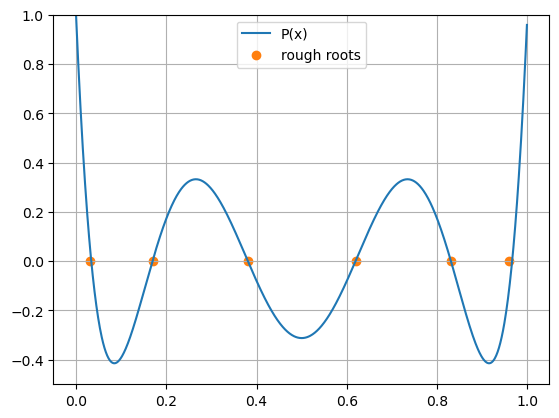

Rough values for the roots: [0.03 0.17 0.38 0.62 0.83 0.96]
Exact values for the roots: [0.03376524 0.16939531 0.38069041 0.61930959 0.83060469 0.96623476]

Initial guessing of root: 0.03
1: 0.033576198441077475 |dx|=0.0035761984410774745
2: 0.03376473401628287 |dx|=0.00018853557520539615
3: 0.033765242894723296 |dx|=5.088784404312551e-07
4: 0.03376524289842399 |dx|=3.7006912036074105e-12

Root=0.03376524289842399

Exact value of root: 0.033765242898423864
Difference=1.249000902703301e-16
Initial guessing of root: 0.17
1: 0.1693944274297977 |dx|=0.0006055725702023104
2: 0.16939530676505088 |dx|=8.793352531554711e-07
3: 0.16939530676686768 |dx|=1.8168047466335833e-12

Root=0.16939530676686768

Exact value of root: 0.1693953067668677
Difference=-2.7755575615628914e-17
Initial guessing of root: 0.38
1: 0.38069018429439055 |dx|=0.0006901842943905465
2: 0.38069040695837275 |dx|=2.2266398221914548e-07
3: 0.38069040695840195 |dx|=2.92035813676763e-14

Root=0.38069040695840195

Exact value of 

In [4]:
# 2-1


def P(x): 
    return 924*x**6 - 2772*x**5 + 3150*x**4 - 1680*x**3 + 420*x**2 - 42*x + 1


def dP(x): 
    return 5544*x**5 - 13860*x**4 + 12600*x**3 - 5040*x**2 + 840*x - 42 # dP(x)/dx


def rootNewton(f, df, x0, e=1E-11):
    # Find root using Newton method
    # f: f(x) = 0
    # df: df/df
    # x0: initial guess of root
    # e: Loop stops when |dx| <= e

    dx = 1
    i = 0

    while True:
        dx = f(x0)/df(x0)
        x0 -= dx
        i += 1
        print(f"{i}: {x0} |dx|={np.abs(dx)}")

        if np.abs(dx) < e:
            break

    return x0


x = np.arange(0, 1, 0.001)
y = P(x)

root_rough = np.array([0.03, 0.17, 0.38, 0.62, 0.83, 0.96])
root_true = (np.polynomial.legendre.legroots(np.polynomial.legendre.Legendre.basis(6).coef)+1)/2 # Exact value of roots

plt.plot(x, y, label='P(x)')
plt.ylim(-0.5, 1)
plt.scatter(root_rough, np.zeros_like(root_rough), label='rough roots', color='C1')
plt.legend()
plt.grid()
plt.show()

print(f"Rough values for the roots: {root_rough}")
print(f"Exact values for the roots: {root_true}\n")

root_numerical = np.zeros_like(root_rough)

for i, r in enumerate(root_rough):
    print(f"Initial guessing of root: {r}")
    root_numerical[i] = rootNewton(P, dP, r)
    print(f"\nRoot={root_numerical[i]}\n")
    print(f"Exact value of root: {root_true[i]}")
    print(f"Difference={root_numerical[i] - root_true[i]}")
    print("===================================================")

# Additional problem: Solving equation using neural network
### 1. linear equation

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [6]:
class linearEqNet(nn.Module):
    # Neural network for solving linear coupled equations
    def __init__(self, w, t):
        super().__init__()
        self.w = w # NxN square matrix
        self.t = t # Nx1 vector
        self.N = w.shape[0]
        self.net = nn.Sequential(
            nn.Linear(1, self.N, bias=False),
            nn.Linear(self.N, self.N, bias=False)
        )

        with torch.no_grad():
            self.net[1].weight.copy_(w)
            
        for param in self.net[1].parameters():
            param.requires_grad = False


    def run_train(self, epochs, lr=0.01):
        optimizer = optim.SGD(self.net.parameters(), lr=lr)
        loss_list = np.zeros(epochs)

        for epoch in range(epochs):
            optimizer.zero_grad()
            output = self.net(torch.tensor([1.0]))
            loss = ((output - self.t)**2).mean()
            loss.backward()
            optimizer.step()
            loss_list[epoch] = loss.item()

            if (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")

        return loss_list


    def prediction(self):
        with torch.no_grad():  # No need to compute gradients during testing
            predictions = self.net(torch.tensor([1.0]))  # Get the output (predicted value)

            param = self.net[0].weight
            return param, predictions

Epoch 100/1000, Loss: 0.1543986052274704
Epoch 200/1000, Loss: 0.0007146026473492384
Epoch 300/1000, Loss: 3.3060825899156043e-06
Epoch 400/1000, Loss: 1.5101553785257238e-08
Epoch 500/1000, Loss: 7.39722380571628e-11
Epoch 600/1000, Loss: 5.214436174516557e-11
Epoch 700/1000, Loss: 5.214436174516557e-11
Epoch 800/1000, Loss: 5.214436174516557e-11
Epoch 900/1000, Loss: 5.214436174516557e-11
Epoch 1000/1000, Loss: 5.214436174516557e-11


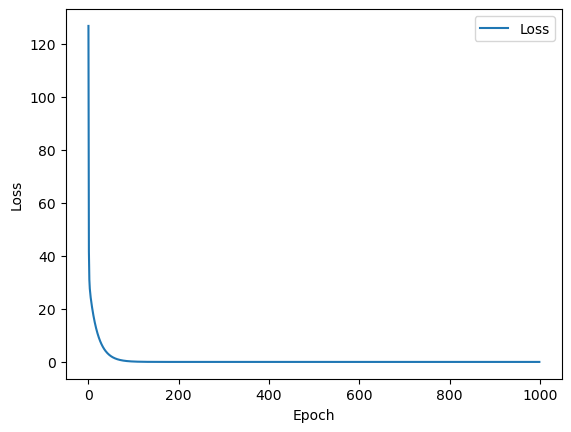

Parameter containing:
tensor([[-0.1327],
        [ 4.1416],
        [ 2.9734]], requires_grad=True)
tensor([12.0000, 15.0000, 18.0000])
tensor([12., 15., 18.])


In [7]:
w = torch.tensor([[4.0, -2.0, 7.0],
                  [7.0, 6.0, -3.0],
                  [2.0, 8.0, -5.0]])

target = torch.tensor([12.0, 15.0, 18.0])


model1 = linearEqNet(w, target)
loss_list = model1.run_train(1000)
x, pred = model1.prediction()

plt.plot(loss_list, label="Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

with torch.no_grad():
    print(x)
    print(pred)
    print(target)

Epoch 100/5000, Loss: 0.6290186643600464
Epoch 200/5000, Loss: 0.1477159857749939
Epoch 300/5000, Loss: 0.055188991129398346
Epoch 400/5000, Loss: 0.02907499112188816
Epoch 500/5000, Loss: 0.017535317689180374
Epoch 600/5000, Loss: 0.01098816841840744
Epoch 700/5000, Loss: 0.0069526731967926025
Epoch 800/5000, Loss: 0.004409730434417725
Epoch 900/5000, Loss: 0.0027984604239463806
Epoch 1000/5000, Loss: 0.0017762064235284925
Epoch 1100/5000, Loss: 0.0011273915879428387
Epoch 1200/5000, Loss: 0.000715588394086808
Epoch 1300/5000, Loss: 0.00045420759124681354
Epoch 1400/5000, Loss: 0.00028828627546317875
Epoch 1500/5000, Loss: 0.00018299341900274158
Epoch 1600/5000, Loss: 0.0001161554828286171
Epoch 1700/5000, Loss: 7.372519030468538e-05
Epoch 1800/5000, Loss: 4.6794106310699135e-05
Epoch 1900/5000, Loss: 2.9705091947107576e-05
Epoch 2000/5000, Loss: 1.8858376279240474e-05
Epoch 2100/5000, Loss: 1.1971146705036517e-05
Epoch 2200/5000, Loss: 7.601736797369085e-06
Epoch 2300/5000, Loss: 4.8

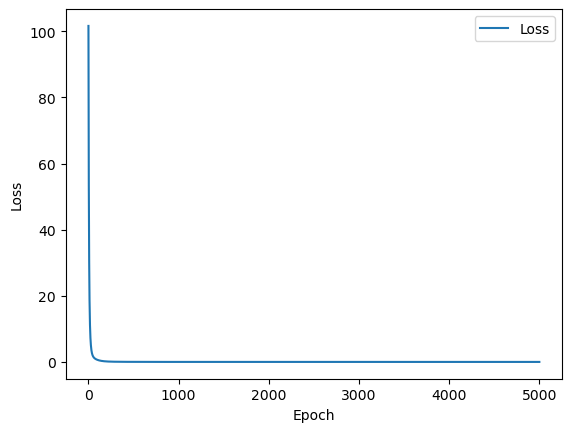

Parameter containing:
tensor([[2.9231],
        [1.2308],
        [1.6154],
        [4.2307]], requires_grad=True)
tensor([10.0000,  2.0000,  8.0000, 15.0000])
tensor([10.,  2.,  8., 15.])


In [8]:
w = torch.tensor([[1.0, 1.0, 1.0, 1.0],
                  [2.0, -1.0, 1.0, -1.0],
                  [1.0, 2.0, -1.0, 1.0],
                  [3.0, -1.0, 2.0, 1.0]])

target = torch.tensor([10.0, 2.0, 8.0, 15.0])


model2 = linearEqNet(w, target)
loss_list = model2.run_train(5000)
x, pred = model2.prediction()

plt.plot(loss_list, label="Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

with torch.no_grad():
    print(x)
    print(pred)
    print(target)

# 2. nonlinear equation

In [9]:
class nonlinearEqNet(nn.Module):
    # Neural network for solving linear coupled equations
    # Case: x^2 - ln(x) - 1 = 0 (S.K. Jeswal (2018), https://doi.org/10.1016/j.asoc.2018.09.003)
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1,1, bias=False)


    def forward(self):
        x = self.linear(torch.tensor([1.0]))
        y1 = torch.pow(x, 2)
        y2 = torch.log(x)
        x = y1 - y2 - 1
        return x
    

    def run_train(self, x0, epochs, lr=0.01):
        # x0: initial guess of root
        with torch.no_grad():
            self.linear.weight.fill_(x0)
        optimizer = optim.SGD(self.linear.parameters(), lr=lr)
        loss_list = np.zeros(epochs)

        for epoch in range(epochs):
            optimizer.zero_grad()
            output = self.forward()
            loss = ((output)**2).mean()
            loss.backward()
            optimizer.step()
            loss_list[epoch] = loss.item()

            if (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")

        return loss_list


    def prediction(self):
        with torch.no_grad():  # No need to compute gradients during testing
            predictions = self.forward()  # Get the output (predicted value)

            param = self.linear.weight
            return param, predictions

Epoch 100/500, Loss: 4.386960426927544e-06
Epoch 200/500, Loss: 3.65288599368796e-09
Epoch 300/500, Loss: 2.7853275241795927e-12
Epoch 400/500, Loss: 2.2737367544323206e-13
Epoch 500/500, Loss: 2.2737367544323206e-13


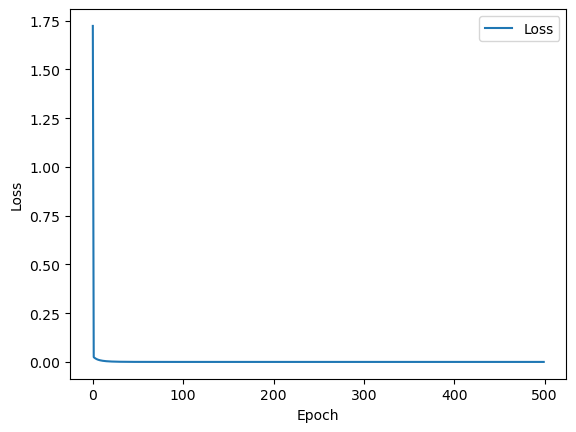

Parameter containing:
tensor([[0.4508]], requires_grad=True)
tensor([4.7684e-07])


In [10]:
model_nonlin = nonlinearEqNet()
loss_list = model_nonlin.run_train(0.1, 500)
x, pred = model_nonlin.prediction()

plt.plot(loss_list, label="Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

with torch.no_grad():
    print(x)
    print(pred)

Epoch 100/1000, Loss: 0.0234830342233181
Epoch 200/1000, Loss: 0.022927220910787582
Epoch 300/1000, Loss: 0.018276257440447807
Epoch 400/1000, Loss: 0.0049360222183167934
Epoch 500/1000, Loss: 0.00022305115999188274
Epoch 600/1000, Loss: 4.626085228665033e-06
Epoch 700/1000, Loss: 8.315568322814215e-08
Epoch 800/1000, Loss: 1.4688659177863883e-09
Epoch 900/1000, Loss: 2.689048983484099e-11
Epoch 1000/1000, Loss: 2.220446049250313e-12


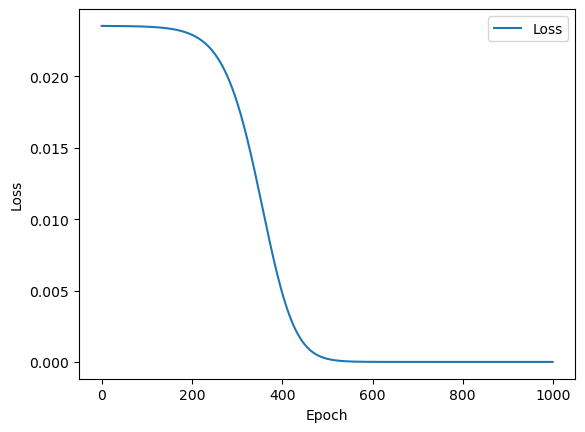

Parameter containing:
tensor([[1.0000]], requires_grad=True)
tensor([-1.4901e-06])


In [11]:
model_nonlin = nonlinearEqNet()
loss_list = model_nonlin.run_train(0.71, 1000)
x, pred = model_nonlin.prediction()

plt.plot(loss_list, label="Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

with torch.no_grad():
    print(x)
    print(pred)